# 🛒 Analiza i Klasterizacija E-commerce Prodaje
### Amazon Sale Report — Segmentacija Kupaca pomocu Nenadgledanog Ucenja

---
> **Autor:** Aleksandra Djokic  
> **Predmet:** Masinsko ucenje  
> **Dataset:** Amazon Sale Report (128,975 transakcija)

## 1. Cilj projekta

Ovaj projekat ima sledece konkretne ciljeve:

1. **Eksplorativna analiza podataka (EDA)** — razumevanje distribucije, trendova i anomalija
2. **Predobrada podataka** — ciscenje, kodiranje kategorijskih promenljivih i skaliranje
3. **Redukcija dimenzionalnosti (PCA)** — smanjenje kompleksnosti uz zadrzavanje informacija
4. **Poredjenje algoritama klasterizacije** — KMeans, Hijerarhijska klasterizacija, DBSCAN
5. **Profilisanje i imenovanje segmenata** — davanje poslovnog znacenja otkrivenim grupama
6. **Strateske preporuke** — konkretni akcioni planovi za svaki identifikovani segment

## 2. Dataset Overview

Dataset **Amazon Sale Report** sadrži ~128.975 transakcija sa Amazon India platforme.

| Kolona | Tip | Opis |
|---|---|---|
| **Order ID** | string |  ID svake porudžbine |
| **Date** | datetime | Datum kupovine |
| **Status** | categorical | Gde je porudžbina sada, isporučena, otkazana, u toku... |
| **Fulfilment** | categorical | Ko šalje — Amazon ili prodavac |
| **Sales Channel** | categorical | Platforma kroz koju je kupovina napravljena |
| **ship-service-level** | categorical | Standardna ili ekspresna dostava |
| **Category** | categorical | Vrsta proizvoda (kurta, haljina, set...) |
| **Size** | categorical | Veličina artikla (S, M, L, XL...) |
| **Qty** | integer | Koliko komada je poručeno |
| **Amount** | float | Ukupna vrednost porudžbine u INR |
| **ship-city / ship-state** | string | Grad i država dostave |
| **ship-postal-code** | float | Poštanski broj |
| **B2B** | boolean | Da li kupuje firma (B2B) ili privatno lice |
| **Courier Status** | categorical | Status kurirske isporuke |
| **promotion-ids** | string | Koji popust je iskorišćen (ako postoji) |
| **fulfilled-by** | categorical | Koji servis je obavio isporuku |

Obeležja korišćena za klasterizaciju: `Category`, `Size`, `Qty`, `Amount`, `Courier Status`.

## 3. Hipoteze Istrazivanja

Pre nego sto primenimo algoritme klasterizacije, formulisemo istrazivacke hipoteze zasnovane na poslovnoj logici  e-commerce trzista. Ove hipoteze nam sluze kao okvir za interpretaciju rezultata.

### Hipoteza 1 — 'Budget' kupci (Kupci orijentisani na cenu)

Karakteristike: Visok `Qty`, nizak `Amount` po artiklu, ceste porudzbine standardnih kategorija (majice, pantalone).

### Hipoteza 2 — 'Premium' kupci (Kupci visokih vrednosti)

Karakteristike: Nizak `Qty`, visok `Amount`, premium kategorije, cesta upotreba ekspresne dostave (`Expedited`).

### Hipoteza 3 — 'Bulk' kupci (Poslovni entiteti / B2B)

Karakteristike: Visok `Qty`, visok ukupni `Amount`, `B2B = True`, regularni vremenski intervali izmedju porudzbina.


### Pregled hipoteza

| Segment | Qty | Amount | Frekvencija | B2B | Strategija |
|---|---|---|---|---|---|
| **Budget kupci** | Visok | Nizak | Visoka | Ne | Popusti, akcije |
| **Premium kupci** | Nizak | Visok | Srednja | Ne | VIP program, personalizacija |
| **Bulk / B2B kupci** | Visok | Visok | Regularna | Da | B2B ugovori, volume pricing |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## 1. Ucitavanje i ciscenje podataka

In [3]:
data = pd.read_csv('Amazon Sale Report.csv', low_memory=False)
data.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [5]:
data.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

### 1.1. Ciscenje podataka

Uklanjamo nepotrebne kolone, redove sa nedostajucim vrednostima za `Amount` i konvertujemo `Date` u datetime format.

In [9]:

cols_to_drop = ['promotion-ids', 'Unnamed: 22', 'fulfilled-by', 'ship-country']
data.drop(columns=cols_to_drop, inplace=True, errors='ignore')

data.dropna(subset=['Amount'], inplace=True)

data['Date'] = pd.to_datetime(data['Date'])

## 2. Eksplorativna analiza podataka (EDA)

Pre predobrade, analiziramo osnovne karakteristike podataka: vremenske trendove, distribuciju kategorija i kreiranje novih obelezja.

     Month  Ukupna_prodaja  Broj_porudzbina Month_str
0  2022-03       101683.85              162   2022-03
1  2022-04     28838708.32            46068   2022-04
2  2022-05     26226476.75            39536   2022-05
3  2022-06     23425809.38            35414   2022-06


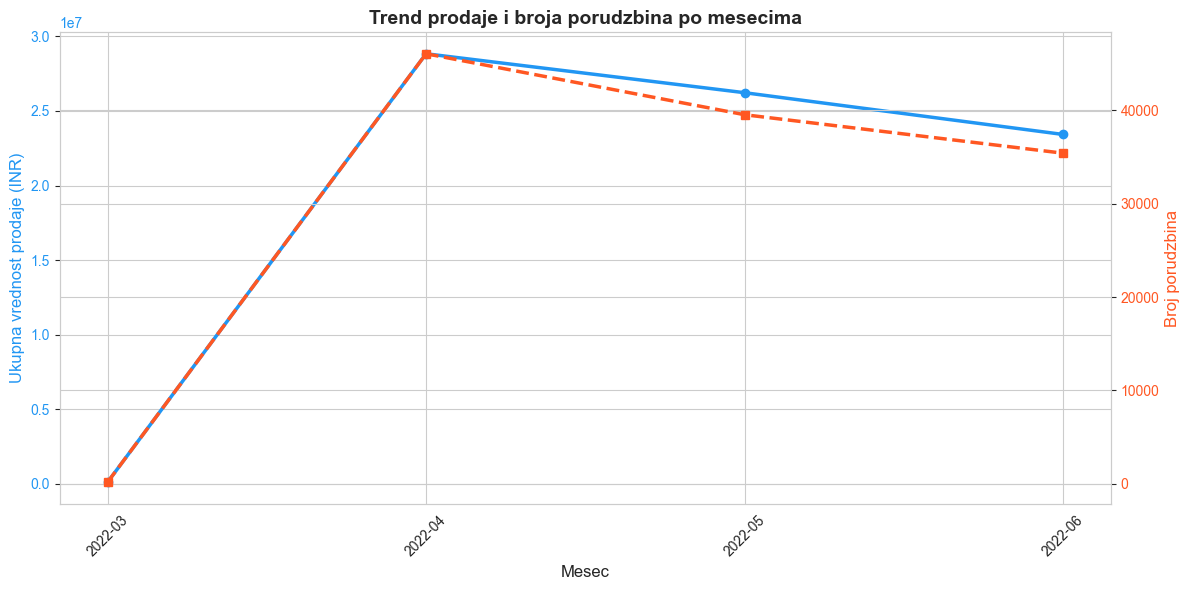

In [10]:
# Analiza vremenskih trendova (Prodaja po mesecima)
data['Month'] = data['Date'].dt.to_period('M')

monthly_stats = data.groupby('Month').agg(
    Ukupna_prodaja=('Amount', 'sum'),
    Broj_porudzbina=('Amount', 'count')
).reset_index()
monthly_stats['Month_str'] = monthly_stats['Month'].astype(str)

print(monthly_stats)

# Vizualizacija: prodaja i broj porudzbina
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Mesec', fontsize=12)
ax1.set_ylabel('Ukupna vrednost prodaje (INR)', color='#2196F3', fontsize=12)
ax1.plot(monthly_stats['Month_str'], monthly_stats['Ukupna_prodaja'],
         color='#2196F3', marker='o', linewidth=2.5, label='Ukupna prodaja')
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Broj porudzbina', color='#FF5722', fontsize=12)
ax2.plot(monthly_stats['Month_str'], monthly_stats['Broj_porudzbina'],
         color='#FF5722', marker='s', linewidth=2.5, linestyle='--', label='Broj porudzbina')
ax2.tick_params(axis='y', labelcolor='#FF5722')

plt.title('Trend prodaje i broja porudzbina po mesecima', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

 Tabela Kardinalnosti 
    Kolona  Broj jedinstvenih vrednosti
  Category                            9
      Size                           11
 ship-city                         8704
ship-state                           68


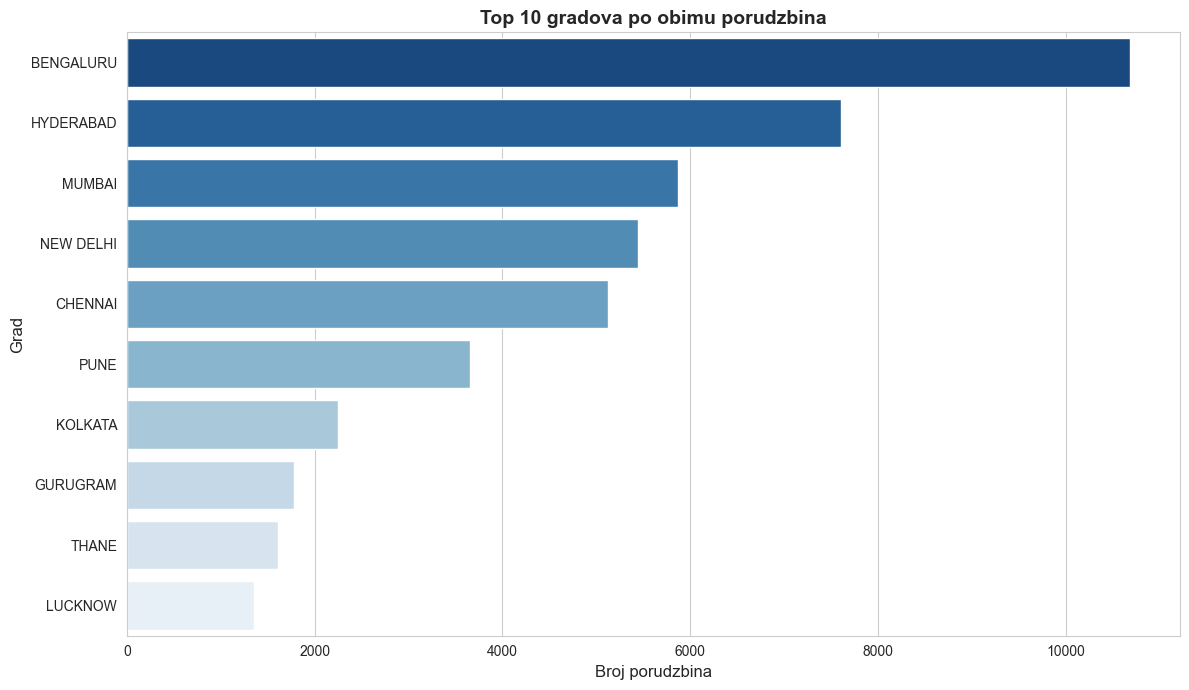

In [11]:
# Kardinalnost i distribucija kategorija
cardinality_cols = ['Category', 'Size', 'ship-city', 'ship-state']
cardinality_df = pd.DataFrame({
    'Kolona': cardinality_cols,
    'Broj jedinstvenih vrednosti': [data[col].nunique() for col in cardinality_cols]
})
print(' Tabela Kardinalnosti ')
print(cardinality_df.to_string(index=False))

# Top 10 gradova po broju porudzbina
top10_cities = data['ship-city'].value_counts().head(10).reset_index()
top10_cities.columns = ['Grad', 'Broj porudzbina']

plt.figure(figsize=(12, 7))
sns.barplot(data=top10_cities, x='Broj porudzbina', y='Grad', palette='Blues_r')
plt.title('Top 10 gradova po obimu porudzbina', fontsize=14, fontweight='bold')
plt.xlabel('Broj porudzbina', fontsize=12)
plt.ylabel('Grad', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# Feature Engineering (Total Revenue)
# Kreiramo novu kolonu kao proizvod kolicine i iznosa za ukupan prihod po transakciji
data['Total_Revenue'] = data['Qty'] * data['Amount']

print('=== Prvih 5 redova sa kolonom Total_Revenue ===')
print(data[['Qty', 'Amount', 'Total_Revenue']].head())
print(f'\nUkupan prihod u datasetu: {data["Total_Revenue"].sum():,.2f} INR')
print(f'Prosecan prihod po transakciji: {data["Total_Revenue"].mean():,.2f} INR')

=== Prvih 5 redova sa kolonom Total_Revenue ===
   Qty  Amount  Total_Revenue
0    0  647.62            0.0
1    1  406.00          406.0
2    1  329.00          329.0
3    0  753.33            0.0
4    1  574.00          574.0

Ukupan prihod u datasetu: 76,034,406.00 INR
Prosecan prihod po transakciji: 627.45 INR


## 3. Predobrada podataka

### 3.1. Detekcija i obrada outliera (Winsorizacija)

Outlieri u koloni `Amount` mogu drasticno pomeriti centroid klastera. Zato koristimo Winsorizaciju, sve vrednosti iznad 95. percentila se spustaju na vrednost 95. percentila:

```
Pre:   [50, 200, 450, 600, 800, 15.000]  ← outlier remeti centroid
Posle: [50, 200, 450, 600, 800,  1.176]  ← vrednost 'sabijena' na 95. percentil
```


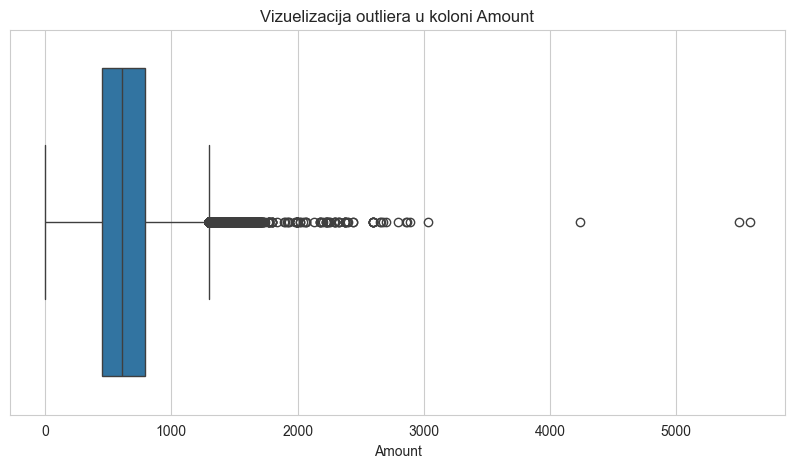

In [13]:

plt.figure(figsize=(10, 5))
sns.boxplot(x=data['Amount'])
plt.title('Vizuelizacija outliera u koloni Amount')
plt.show()

In [14]:
# Vinsorizacija:: 
data['Amount'] = data['Amount'].clip(upper=data['Amount'].quantile(0.95))

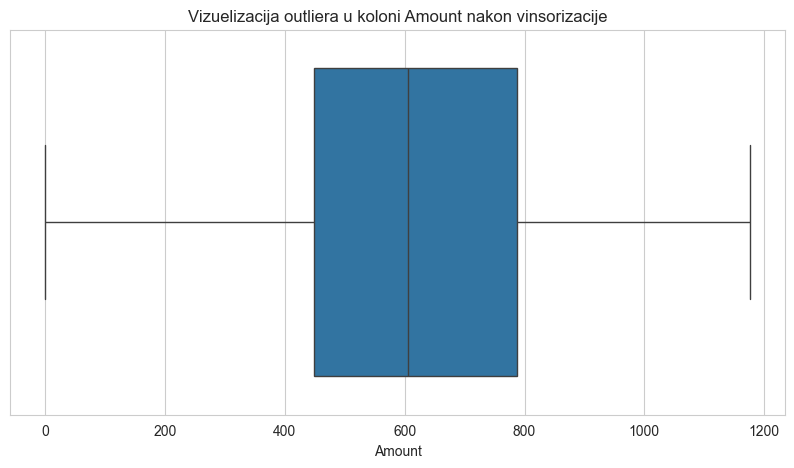

In [15]:

data.describe()
plt.figure(figsize=(10, 5))
sns.boxplot(x=data['Amount'])
plt.title('Vizuelizacija outliera u koloni Amount nakon vinsorizacije')
plt.show()

### 3.2. Kodiranje i skaliranje podataka

In [16]:
#Kodiranje
le = LabelEncoder()

for col in ['Category', 'Size', 'Courier Status']:
    data[col] = le.fit_transform(data[col].astype(str))

features = ['Category', 'Size', 'Qty', 'Amount', 'Courier Status']
X = data[features]

# Provera i uklanjanje NaN vrednosti
print(f"Broj NaN vrednosti pre ciscenja: {X.isna().sum().sum()}")
X_clean = X.dropna()
print(f"Dimenzije nakon uklanjanja NaN: {X_clean.shape}")

# Cuvamo indekse posle ciscenja da bismo mogli da mapiramo klastere nazad na originalne podatke
clean_indices = X_clean.index

#Skaliranje
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

X_scaled[:5]

Broj NaN vrednosti pre ciscenja: 0
Dimenzije nakon uklanjanja NaN: (121180, 5)


array([[-0.9288786 ,  0.22623755, -4.48434507,  0.02947933,  4.11700738],
       [ 1.04255287, -2.21205511,  0.18086445, -0.90518541, -0.30720884],
       [ 1.04255287,  0.57456507,  0.18086445, -1.20304646, -0.30720884],
       [ 0.38540905, -0.4704175 , -4.48434507,  0.43839999,  4.11700738],
       [-0.27173477, -2.21205511,  0.18086445, -0.25530677, -0.30720884]])

## 4. Redukcija dimenzionalnosti (PCA)

Explained Variance Ratio: [0.36394558 0.29457714]
Ukupno zadrzano: 65.85% informacija


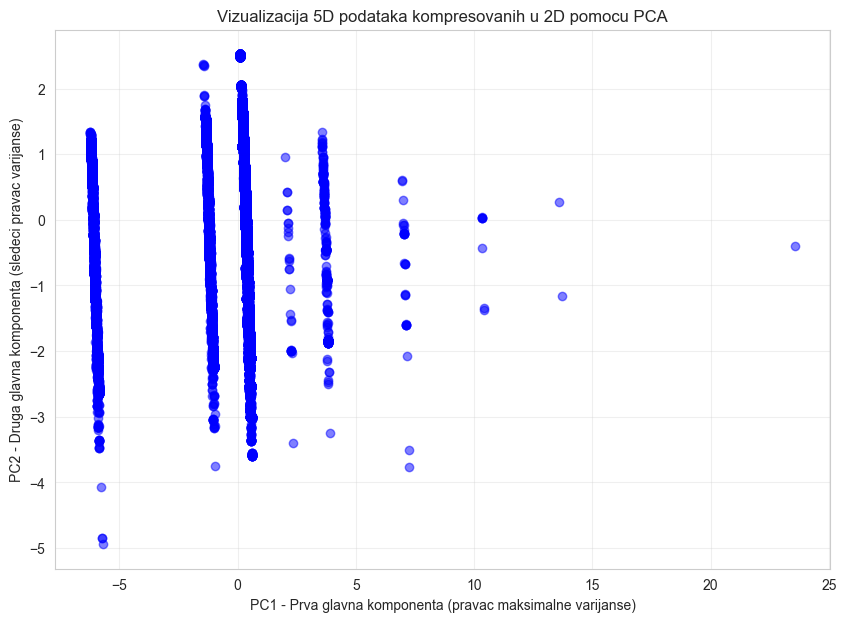

In [17]:
# Inicijalizacija PCA sa 2 komponente
# PCA redukuje 5 dimenzija (Category, Size, Qty, Amount, Courier Status) 
pca = PCA(n_components=2)

# Transformacija skaliranih podataka u 2D prostor
X_pca = pca.fit_transform(X_scaled)

# Ispis objasnjene varijanse
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Ukupno zadrzano: {sum(pca.explained_variance_ratio_)*100:.2f}% informacija")

# Vizualizacija 
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', alpha=0.5)
plt.xlabel('PC1 - Prva glavna komponenta (pravac maksimalne varijanse)')
plt.ylabel('PC2 - Druga glavna komponenta (sledeci pravac varijanse)')
plt.title('Vizualizacija 5D podataka kompresovanih u 2D pomocu PCA')
plt.grid(alpha=0.3)
plt.show()

### 4.1. Napredna vizualizacija: PCA vs t-SNE vs UMAP


t-SNE zavrsen.
UMAP zavrsen.


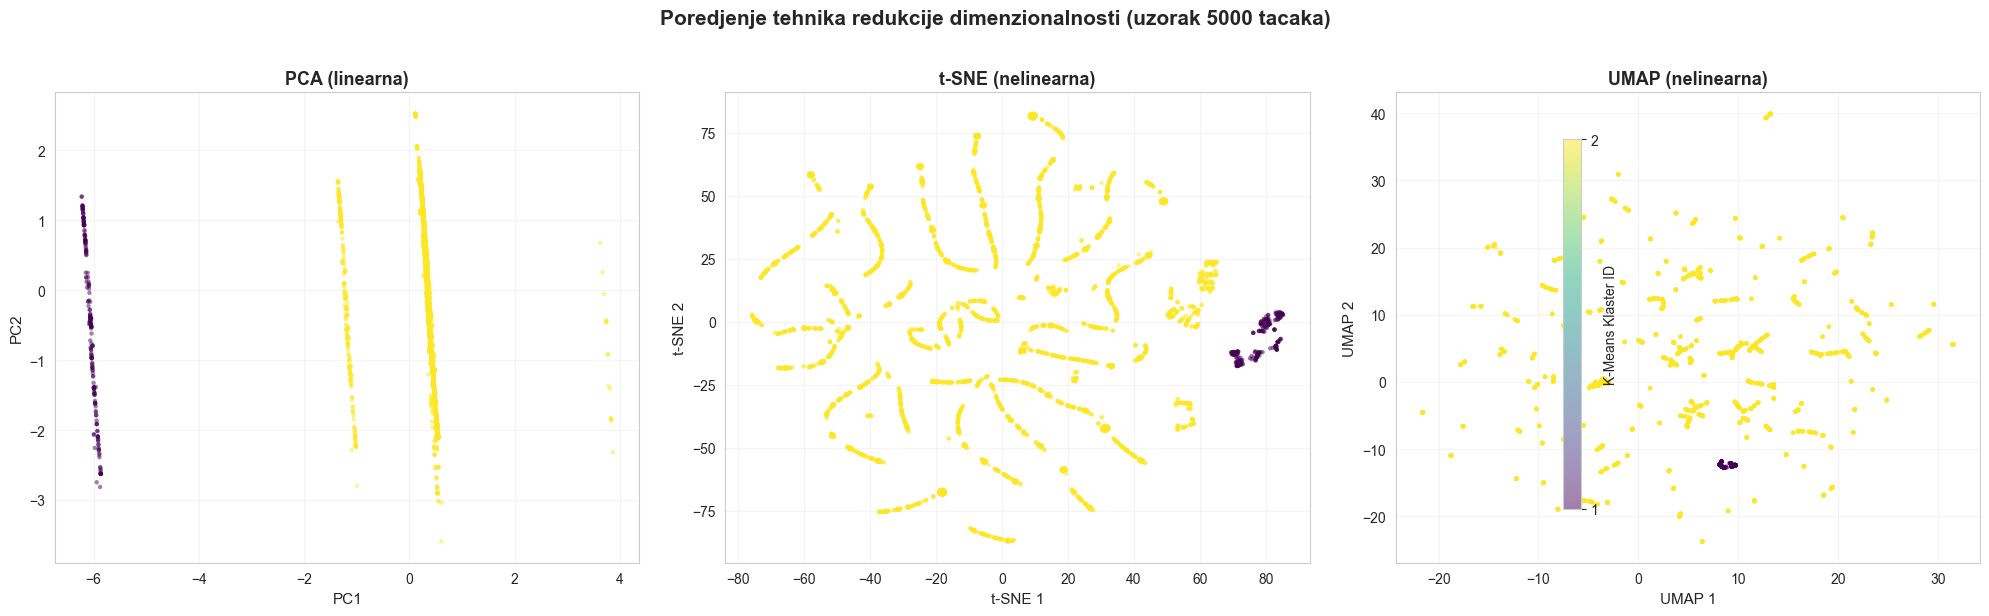

In [19]:
from sklearn.manifold import TSNE
import umap

# Koristimo uzorak od 5000 redova jer su t-SNE i UMAP racunski zahtevni
np.random.seed(42)
viz_sample_idx = np.random.choice(len(X_pca), 5000, replace=False)
X_viz_scaled = X_scaled[viz_sample_idx]
X_viz_pca = X_pca[viz_sample_idx]
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
viz_labels = kmeans_labels[viz_sample_idx]

#t-SNE projekcija 
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_viz_scaled)
print("t-SNE zavrsen.")

# UMAP projekcija 
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_viz_scaled)
print("UMAP zavrsen.")

# Uporedna vizualizacija: PCA vs t-SNE vs UMAP 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cmap = plt.cm.viridis
titles = ['PCA (linearna)', 't-SNE (nelinearna)', 'UMAP (nelinearna)']
data_list = [X_viz_pca, X_tsne, X_umap]
xlabels = ['PC1', 't-SNE 1', 'UMAP 1']
ylabels = ['PC2', 't-SNE 2', 'UMAP 2']

for ax, X_proj, title, xl, yl in zip(axes, data_list, titles, xlabels, ylabels):
    scatter = ax.scatter(X_proj[:, 0], X_proj[:, 1], c=viz_labels,
                         cmap=cmap, alpha=0.5, s=10, edgecolors='none')
    ax.set_xlabel(xl, fontsize=11)
    ax.set_ylabel(yl, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.2)

fig.colorbar(scatter, ax=axes, label='K-Means Klaster ID', ticks=[0, 1, 2, 3], shrink=0.8)
plt.suptitle('Poredjenje tehnika redukcije dimenzionalnosti (uzorak 5000 tacaka)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Klasterizacija

### 5.1. K-Means algoritam

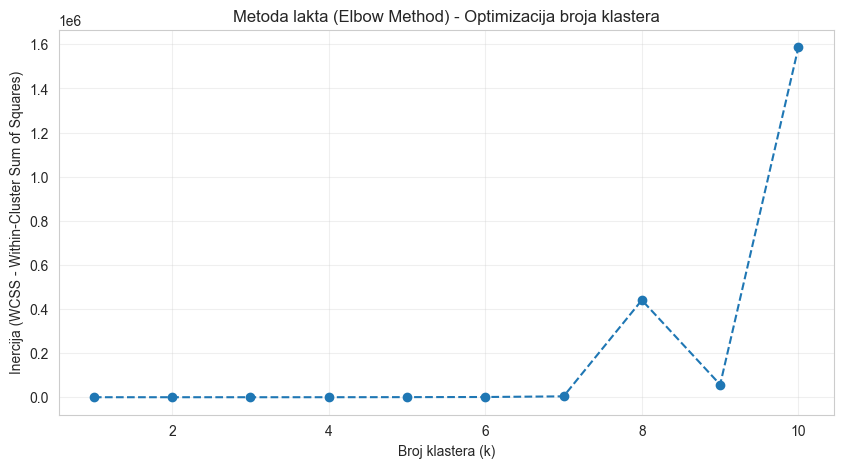

In [20]:
# Elbow Method
wcss = []  

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)  

# Vizualizacija Elbow krive
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metoda lakta (Elbow Method) - Optimizacija broja klastera')
plt.xlabel('Broj klastera (k)')
plt.ylabel('Inercija (WCSS - Within-Cluster Sum of Squares)')
plt.grid(alpha=0.3)
plt.show()

In [21]:
# Treniranje finalnog K-Means modela sa odabranim brojem klastera k=4

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)  # Treniranje i predikcija odjednom

data.loc[clean_indices, 'Cluster_KMeans'] = kmeans_labels

print(f"Broj transakcija po klasteru:")
print(data['Cluster_KMeans'].value_counts().sort_index())

Broj transakcija po klasteru:
Cluster_KMeans
0.0        41
1.0      5136
2.0    116002
3.0         1
Name: count, dtype: int64


### 5.2. Hijerarhijska klasterizacija

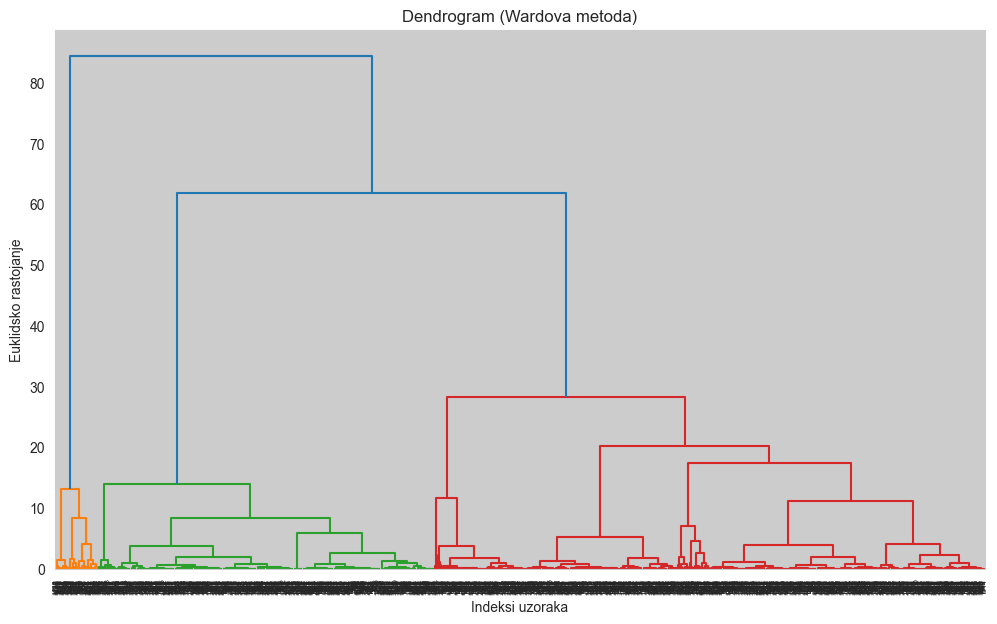

In [23]:
# Taking a random sample of 2000 rows for performance
np.random.seed(42)
sample_indices = np.random.choice(len(X_pca), 2000, replace=False)
X_sample = X_pca[sample_indices]

# Linkage using Ward method
Z = linkage(X_sample, method='ward')

# Plotting the Dendrogram
plt.figure(figsize=(12, 7))
dendrogram(Z)
plt.title('Dendrogram (Wardova metoda)')
plt.xlabel('Indeksi uzoraka')
plt.ylabel('Euklidsko rastojanje')
plt.show()

# Agglomerative Clustering with the same number of clusters as K-Means (k=4)
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_sample)

### 5.3. DBSCAN (Density-Based Spatial Clustering)

Broj pronadjenih klastera: 3
Broj sum tacaka (outlieri): 18
Procenat suma: 0.36%


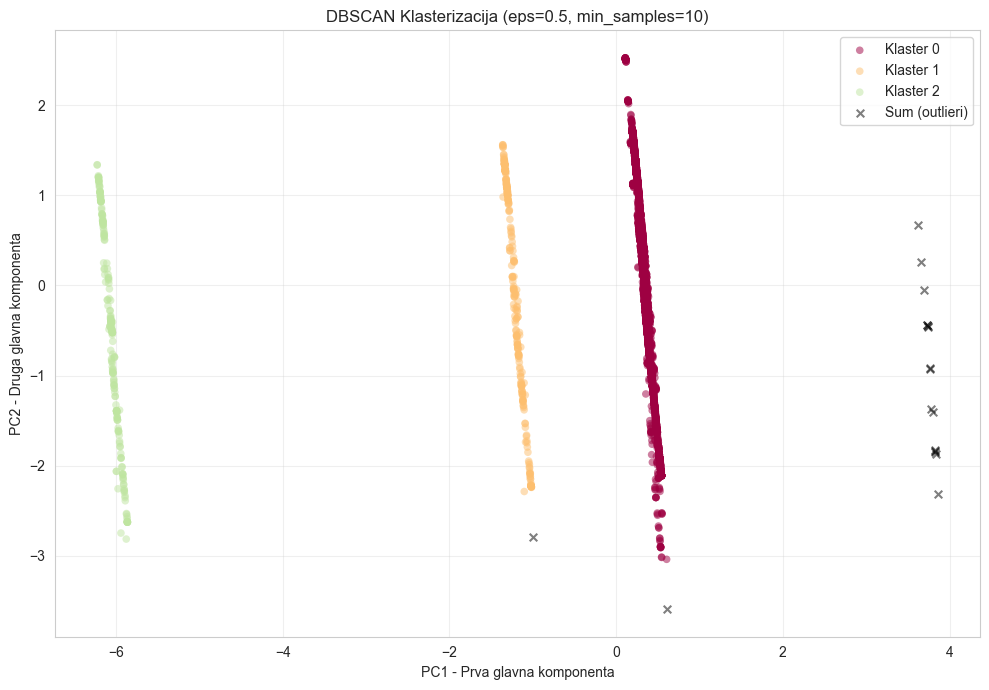


Silhouette Score za DBSCAN (bez suma): 0.3980


In [24]:
from sklearn.cluster import DBSCAN

# Koristimo uzorak od 5000 redova jer je DBSCAN racunski zahtevniji
np.random.seed(42)
dbscan_sample_idx = np.random.choice(len(X_pca), 5000, replace=False)
X_dbscan = X_pca[dbscan_sample_idx]

# Primena DBSCAN algoritma
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_dbscan)

# Analiza rezultata
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Broj pronadjenih klastera: {n_clusters_dbscan}")
print(f"Broj sum tacaka (outlieri): {n_noise}")
print(f"Procenat suma: {(n_noise/len(dbscan_labels))*100:.2f}%")

# Vizualizacija DBSCAN klastera
plt.figure(figsize=(10, 7))
unique_labels = set(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Sum tacke oznacavamo crnom bojom
        col = 'black'
        marker = 'x'
        label = 'Sum (outlieri)'
    else:
        marker = 'o'
        label = f'Klaster {k}'
    
    class_member_mask = (dbscan_labels == k)
    xy = X_dbscan[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, 
                alpha=0.5, s=30, label=label, edgecolors='k' if k == -1 else 'none')

plt.xlabel('PC1 - Prva glavna komponenta')
plt.ylabel('PC2 - Druga glavna komponenta')
plt.title(f'DBSCAN Klasterizacija (eps={dbscan.eps}, min_samples={dbscan.min_samples})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Racunanje Silhouette Score (samo za tacke koje nisu sum)
if n_clusters_dbscan >= 2:
    mask_no_noise = dbscan_labels != -1
    if mask_no_noise.sum() > 1:
        dbscan_sil = silhouette_score(X_dbscan[mask_no_noise], dbscan_labels[mask_no_noise])
        print(f"\nSilhouette Score za DBSCAN (bez suma): {dbscan_sil:.4f}")
    else:
        print("\nNedovoljno tacaka za racunanje Silhouette Score")
else:
    print("\nDBSCAN nije pronasao dovoljno klastera (potrebno minimum 2)")

## 6. Poredjenje algoritama klasterizacije

Za fer poredjenje sva tri modela, treniramo ih na **istom uzorku od 5000 redova** i racunamo tri metrike:
- **Silhouette Score** (blize 1 je bolje) 
- **Calinski-Harabasz Score** (vece je bolje) 
- **Davies-Bouldin Index** (manje je bolje) 

Treniranje modela na uzorku od 5000 redova...
[1/4] KMeans:             Silhouette=0.5881, CH=13418.55, DB=0.5169


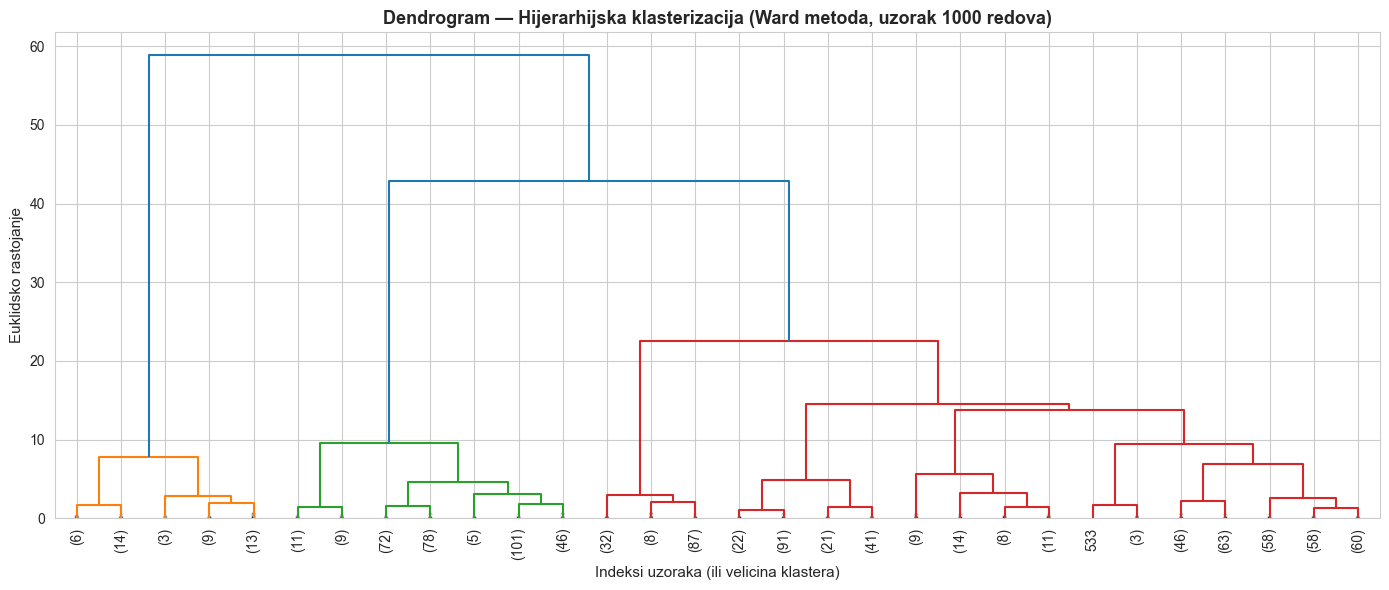

[2/4] Hijerarhijski:      Silhouette=0.5775, CH=12514.24, DB=0.5540
[3/4] GMM:                Silhouette=0.1615, CH=2076.32, DB=1.1935
      (GMM dodatno)        BIC=-6411.06, AIC=-6560.95
[4/4] DBSCAN:             Broj klastera=3, Sum tacaka=18
      DBSCAN:             Silhouette=0.3980, CH=3017.49, DB=1.0359

 Svi modeli istrenirani.


In [26]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Koristimo X_pca (vec izracunato) za sve modele
np.random.seed(42)
sample_idx_battle = np.random.choice(len(X_pca), 5000, replace=False)
X_battle = X_pca[sample_idx_battle]

print('Treniranje modela na uzorku od 5000 redova...')

#  MODEL 1: KMeans
km_battle = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels_battle = km_battle.fit_predict(X_battle)

km_sil = silhouette_score(X_battle, km_labels_battle)
km_ch  = calinski_harabasz_score(X_battle, km_labels_battle)
km_db  = davies_bouldin_score(X_battle, km_labels_battle)
print(f'[1/4] KMeans:             Silhouette={km_sil:.4f}, CH={km_ch:.2f}, DB={km_db:.4f}')

# MODEL 2: Hijerarhijski 
sample_idx_dendro = np.random.choice(len(X_pca), 1000, replace=False)
X_dendro = X_pca[sample_idx_dendro]
linked_dendro = linkage(X_dendro, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked_dendro, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Dendrogram — Hijerarhijska klasterizacija (Ward metoda, uzorak 1000 redova)',
          fontsize=13, fontweight='bold')
plt.xlabel('Indeksi uzoraka (ili velicina klastera)', fontsize=11)
plt.ylabel('Euklidsko rastojanje', fontsize=11)
plt.tight_layout()
plt.show()

hc_battle = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_labels_battle = hc_battle.fit_predict(X_battle)

hc_sil = silhouette_score(X_battle, hc_labels_battle)
hc_ch  = calinski_harabasz_score(X_battle, hc_labels_battle)
hc_db  = davies_bouldin_score(X_battle, hc_labels_battle)
print(f'[2/4] Hijerarhijski:      Silhouette={hc_sil:.4f}, CH={hc_ch:.2f}, DB={hc_db:.4f}')

# MODEL 3: GMM (Gaussian Mixture Model) 
gmm_battle = GaussianMixture(n_components=4, covariance_type='full', random_state=42, max_iter=200)
gmm_labels_battle = gmm_battle.fit_predict(X_battle)

gmm_sil = silhouette_score(X_battle, gmm_labels_battle)
gmm_ch  = calinski_harabasz_score(X_battle, gmm_labels_battle)
gmm_db  = davies_bouldin_score(X_battle, gmm_labels_battle)
gmm_bic = gmm_battle.bic(X_battle)
gmm_aic = gmm_battle.aic(X_battle)
print(f'[3/4] GMM:                Silhouette={gmm_sil:.4f}, CH={gmm_ch:.2f}, DB={gmm_db:.4f}')
print(f'      (GMM dodatno)        BIC={gmm_bic:.2f}, AIC={gmm_aic:.2f}')

# MODEL 4: DBSCAN 
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels_battle = dbscan.fit_predict(X_battle)

db_mask = db_labels_battle != -1
n_clusters_db = len(set(db_labels_battle[db_mask]))
n_noise = np.sum(~db_mask)
print(f'[4/4] DBSCAN:             Broj klastera={n_clusters_db}, Sum tacaka={n_noise}')

if n_clusters_db >= 2 and db_mask.sum() > 1:
    db_sil = silhouette_score(X_battle[db_mask], db_labels_battle[db_mask])
    db_ch  = calinski_harabasz_score(X_battle[db_mask], db_labels_battle[db_mask])
    db_db  = davies_bouldin_score(X_battle[db_mask], db_labels_battle[db_mask])
else:
    db_sil, db_ch, db_db = 0.0, 0.0, 9999.0
    print('      DBSCAN nije pronasao dovoljno klastera za metrike.')

print(f'      DBSCAN:             Silhouette={db_sil:.4f}, CH={db_ch:.2f}, DB={db_db:.4f}')
print('\n Svi modeli istrenirani.')


### 6.1. Tabela poredjenja i proglasenje pobednika

 TABELA POREDjENJA MODELA KLASTERIZACIJE


,Model,Tip,k,"Silhouette ↑ [−1, 1]",Calinski-Harabasz ↑,"Davies-Bouldin ↓ [0, ∞)"
0,K-Means,Centroidni,4,0.5881,13418.55,0.5169
1,Hijerarhijski (Ward),Hijerarhijski,4,0.5775,12514.24,0.5540
2,GMM (Gaussian Mixture),Probabilisticki,4,0.1615,2076.32,1.1935
3,DBSCAN,Gustinski,3 (+18 sum),0.3980,3017.49,1.0359



📊 Rang modela po svakoj metrici (1 = best):


,Model,Rang Silhouette,Rang CH,Rang DB,Zbir rangova
1,K-Means,1,1,1,3
2,Hijerarhijski (Ward),2,2,2,6
3,DBSCAN,3,3,3,9
4,GMM (Gaussian Mixture),4,4,4,12



🏆 POBEDNIK (najmanji zbir rangova): K-Means


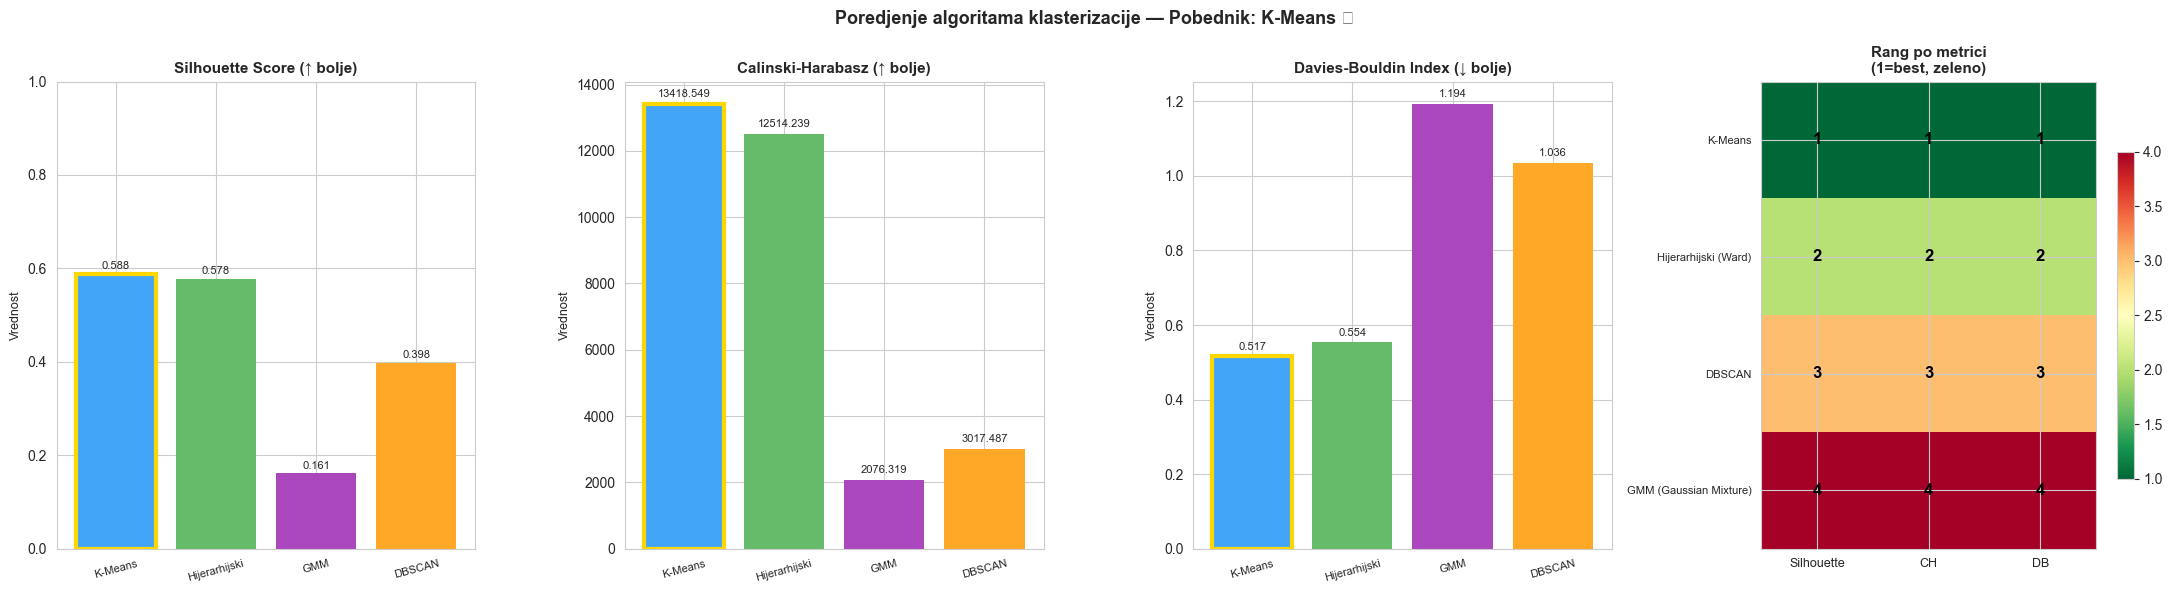

In [27]:

# Tabela poredjenja — 4 modela × 3 + 2 GMM metrike
comparison_data = {
    'Model': [
        'K-Means',
        'Hijerarhijski (Ward)',
        'GMM (Gaussian Mixture)',
        'DBSCAN'
    ],
    'Tip': ['Centroidni', 'Hijerarhijski', 'Probabilisticki', 'Gustinski'],
    'k': [4, 4, 4, f'{n_clusters_db} (+{n_noise} sum)'],
    'Silhouette ↑\n[−1, 1]': [km_sil, hc_sil, gmm_sil, db_sil],
    'Calinski-Harabasz ↑': [km_ch, hc_ch, gmm_ch, db_ch],
    'Davies-Bouldin ↓\n[0, ∞)': [km_db, hc_db, gmm_db, db_db],
}

comp_df = pd.DataFrame(comparison_data)

# Numericke kolone za stilizovanje
sil_col = 'Silhouette ↑\n[−1, 1]'
ch_col  = 'Calinski-Harabasz ↑'
db_col  = 'Davies-Bouldin ↓\n[0, ∞)'

# Zaokruzivanje na 4 decimale samo za numericke kolone
for col in [sil_col, ch_col, db_col]:
    comp_df[col] = pd.to_numeric(comp_df[col], errors='coerce').round(4)


print(" TABELA POREDjENJA MODELA KLASTERIZACIJE")


# Prikaz kao stilizovani DataFrame
def highlight_best(s):
    #Zeleno za pobednika po svakoj metrici.
    if s.name == sil_col or s.name == ch_col:
        is_best = s == s.max()
    elif s.name == db_col:
        is_best = s == s.min()
    else:
        return [''] * len(s)
    return ['background-color: #c8f7c5; font-weight: bold' if v else '' for v in is_best]

styled = (comp_df.style
          .apply(highlight_best, subset=[sil_col, ch_col, db_col])
          .format({sil_col: '{:.4f}', ch_col: '{:.2f}', db_col: '{:.4f}'})
          .set_caption('Zeleno = pobednik po metrici | ↑ vece je bolje | ↓ manje je bolje')
          .set_table_styles([
              {'selector': 'caption',
               'props': [('font-size', '11px'), ('color', '#555'), ('text-align', 'center')]},
              {'selector': 'th',
               'props': [('background-color', '#2c3e50'), ('color', 'white'),
                         ('font-size', '11px'), ('text-align', 'center')]},
              {'selector': 'td',
               'props': [('text-align', 'center'), ('font-size', '11px')]},
          ]))
display(styled)

# Rang po svakoj metrici
ranks = pd.DataFrame({
    'Model': comp_df['Model'],
    'Rang Silhouette': comp_df[sil_col].rank(ascending=False).astype(int),
    'Rang CH':         comp_df[ch_col].rank(ascending=False).astype(int),
    'Rang DB':         comp_df[db_col].rank(ascending=True).astype(int),
})
ranks['Zbir rangova'] = ranks[['Rang Silhouette', 'Rang CH', 'Rang DB']].sum(axis=1)
ranks = ranks.sort_values('Zbir rangova').reset_index(drop=True)
ranks.index += 1
print("\n📊 Rang modela po svakoj metrici (1 = best):")
display(ranks)

winner_name = ranks.iloc[0]['Model']
print(f"\n🏆 POBEDNIK (najmanji zbir rangova): {winner_name}")

# Vizualizacija — 3 subplot-a + rang heatmapa
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

models_short  = ['K-Means', 'Hijerarhijski', 'GMM', 'DBSCAN']
col_colors    = ['#42A5F5', '#66BB6A', '#AB47BC', '#FFA726']
winner_idx    = models_short.index(winner_name) if winner_name in models_short else 0
edge_colors   = ['#FFD700' if i == winner_idx else 'none' for i in range(4)]
edge_widths   = [3 if i == winner_idx else 0 for i in range(4)]

metrics = [
    (axes[0], [km_sil, hc_sil, gmm_sil, db_sil], 'Silhouette Score (↑ bolje)', (0, 1)),
    (axes[1], [km_ch,  hc_ch,  gmm_ch,  db_ch],  'Calinski-Harabasz (↑ bolje)', None),
    (axes[2], [km_db,  hc_db,  gmm_db,  db_db],  'Davies-Bouldin Index (↓ bolje)', None),
]

for ax, vals, title, ylim in metrics:
    bars = ax.bar(models_short, vals, color=col_colors,
                  edgecolor=edge_colors, linewidth=edge_widths)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Vrednost', fontsize=9)
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    if ylim:
        ax.set_ylim(*ylim)
    for bar_obj, v in zip(bars, vals):
        ax.text(bar_obj.get_x() + bar_obj.get_width() / 2,
                bar_obj.get_height() + max(vals) * 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# Rang heatmapa
rank_matrix = ranks.set_index('Model')[['Rang Silhouette', 'Rang CH', 'Rang DB']].astype(float)
im = axes[3].imshow(rank_matrix.values, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=4)
axes[3].set_xticks(range(3))
axes[3].set_xticklabels(['Silhouette', 'CH', 'DB'], fontsize=9)
axes[3].set_yticks(range(len(rank_matrix)))
axes[3].set_yticklabels(rank_matrix.index, fontsize=8)
axes[3].set_title('Rang po metrici\n(1=best, zeleno)', fontsize=11, fontweight='bold')
for i in range(len(rank_matrix)):
    for j in range(3):
        axes[3].text(j, i, int(rank_matrix.values[i, j]),
                     ha='center', va='center', fontsize=12, fontweight='bold', color='black')
plt.colorbar(im, ax=axes[3], shrink=0.7)

plt.suptitle(f'Poredjenje algoritama klasterizacije — Pobednik: {winner_name} ⭐',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Profilisanje i poslovna strategija

### 7.1. Profilisanje klastera (Statisticka analiza)

Grupisemo podatke prema klasterima pobednickog modela (KMeans) i racunamo srednje i medijalne vrednosti za `Amount` i `Qty`.

=== PROFIL KLASTERA (KMeans) ===
 Cluster_KMeans  Mean_Amount  Median_Amount  Mean_Qty  Median_Qty  Count
            0.0      1146.95        1176.00      3.29         3.0     41
            1.0       617.11         600.95      0.00         0.0   5136
            2.0       640.83         605.00      1.00         1.0 116002
            3.0      1176.00        1176.00      8.00         8.0      1


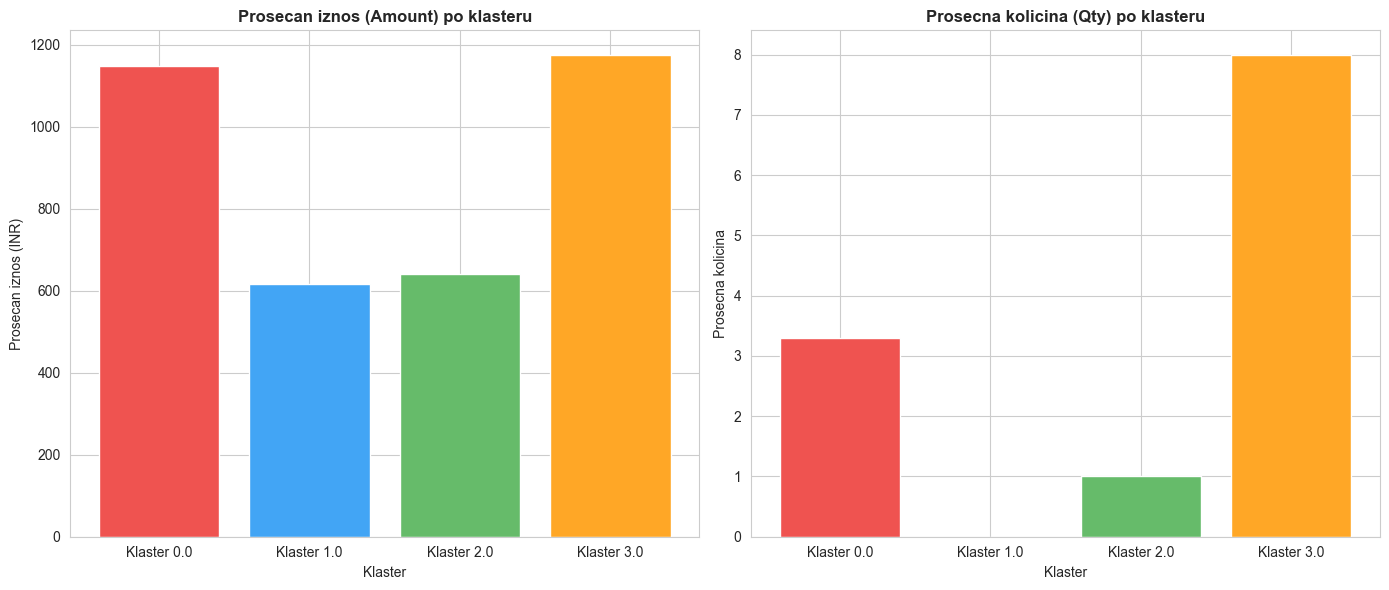

In [28]:
# Profilisanje klastera koristeci KMeans labele na celom datasetu

cluster_profile = data.groupby('Cluster_KMeans').agg(
    Mean_Amount=('Amount', 'mean'),
    Median_Amount=('Amount', 'median'),
    Mean_Qty=('Qty', 'mean'),
    Median_Qty=('Qty', 'median'),
    Count=('Amount', 'count')
).reset_index()

cluster_profile = cluster_profile.round(2)

print('=== PROFIL KLASTERA (KMeans) ===')
print(cluster_profile.to_string(index=False))

# Vizuelizacija profila
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cluster_labels_str = [f'Klaster {i}' for i in cluster_profile['Cluster_KMeans']]

axes[0].bar(cluster_labels_str, cluster_profile['Mean_Amount'],
            color=['#EF5350', '#42A5F5', '#66BB6A', '#FFA726'])
axes[0].set_title('Prosecan iznos (Amount) po klasteru', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Klaster')
axes[0].set_ylabel('Prosecan iznos (INR)')

axes[1].bar(cluster_labels_str, cluster_profile['Mean_Qty'],
            color=['#EF5350', '#42A5F5', '#66BB6A', '#FFA726'])
axes[1].set_title('Prosecna kolicina (Qty) po klasteru', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Klaster')
axes[1].set_ylabel('Prosecna kolicina')

plt.tight_layout()
plt.show()

### 7.2. Statisticka validacija klastera — Hi-kvadrat test (χ²)

Da bismo potvrdili da klasteri zaista odrazavaju smislene razlike u podacima, koristimo **Hi-kvadrat test nezavisnosti** (Chi-Square test of independence). Ovaj test proverava da li postoji **statisticki znacajna veza** izmedju kategorijskog obelezja i pripadnosti klasteru.

- **H₀ (nulta hipoteza):** Obelezje i klaster su nezavisni (nema veze)
- **H₁ (alternativna hipoteza):** Obelezje i klaster NISU nezavisni (postoji veza)
- **Prag znacajnosti:** p-value < 0.05 → odbacujemo H₀ → obelezje znacajno doprinosi segmentaciji

  HI-KVADRAT TEST NEZAVISNOSTI: Obelezje × K-Means klaster


,Obelezje,χ² statistika,p-vrednost,Stepeni slobode,Cramers_V,Znacajnost
0,Category,142.23,9.06e-19,24,0.0198,Veoma znacajno
1,Size,115.31,6.16e-12,30,0.0178,Veoma znacajno
2,Courier Status,2.52,2.84e-01,2,0.0047,Nije znacajno



 Od 3 testiranih obelezja, 2 pokazuju statisticki znacajnu vezu sa klasterima.

 Najjaca asocijacija: Category (Cramér's V = 0.0198)
   → Ovo obelezje najvise doprinosi razlikovanju segmenata kupaca.


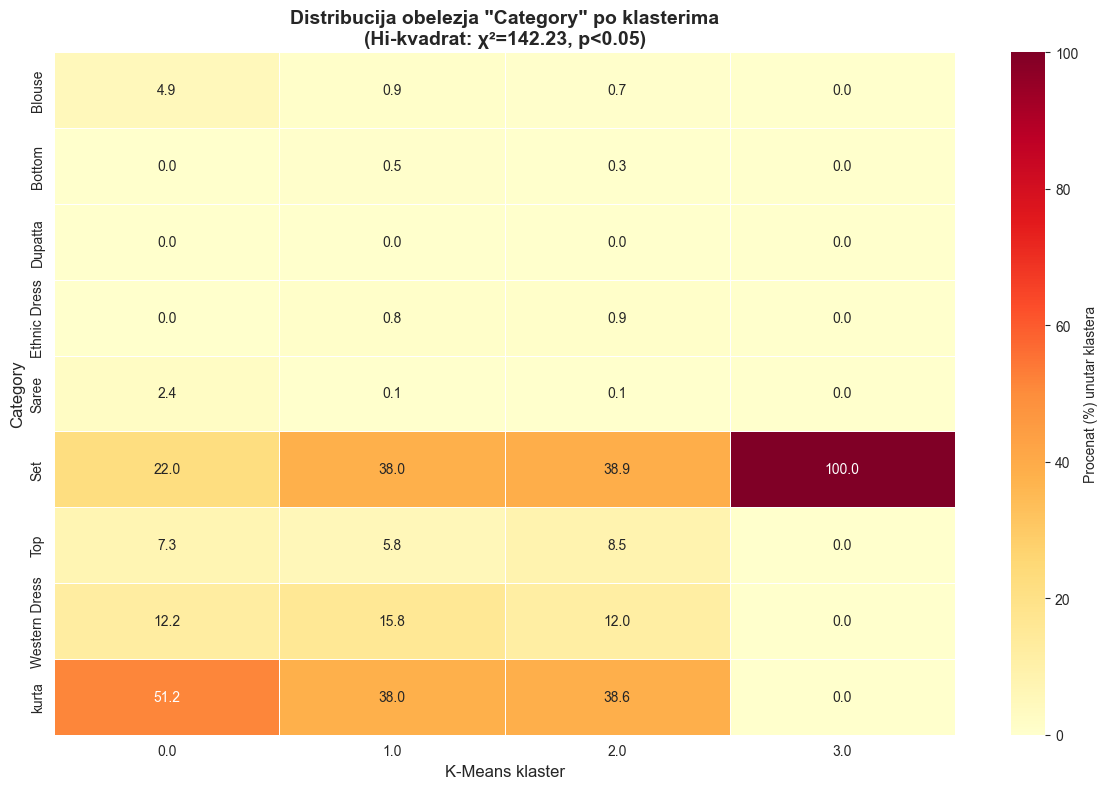


 Heatmapa prikazuje procentualnu zastupljenost svake vrednosti obelezja 'Category' unutar svakog klastera.
   Vece razlike izmedju kolona ukazuju na bolju separaciju klastera.


In [30]:
# Hi-kvadrat test nezavisnosti: kategorijska obelezja vs Klaster
from scipy.stats import chi2_contingency

# Radimo samo sa redovima koji imaju dodeljen klaster
data_with_clusters = data.loc[clean_indices].copy()

# Ponovo ucitavamo originalne (nekodovane) vrednosti za lepsi prikaz
raw = pd.read_csv('Amazon Sale Report.csv', low_memory=False)
raw = raw.loc[clean_indices]  # isti redovi

# Kategorijska obelezja koja testiramo
categorical_features = ['Category', 'Size', 'Courier Status']

#Tabela p-vrednosti za sva kategorijska obelezja 
chi2_results = []

for feature in categorical_features:
    # Kontingencijska tabela: originalne vrednosti × klaster
    contingency = pd.crosstab(raw[feature], data_with_clusters['Cluster_KMeans'])
    
    # Hi-kvadrat test
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    # Cramér's V (0 = nema, 1 = savrsena)
    n = contingency.sum().sum()
    k = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    
    # Interpretacija 
    if p_value < 0.001:
        znacajnost = ' Veoma znacajno'
    elif p_value < 0.01:
        znacajnost = ' Znacajno'
    elif p_value < 0.05:
        znacajnost = ' Marginalno znacajno'
    else:
        znacajnost = ' Nije znacajno'
    
    chi2_results.append({
        'Obelezje': feature,
        'χ² statistika': round(chi2, 2),
        'p-vrednost': f'{p_value:.2e}',
        'Stepeni slobode': dof,
        'Cramers_V': round(cramers_v, 4),
        'Znacajnost': znacajnost
    })

# Prikaz rezultata u tabeli
chi2_df = pd.DataFrame(chi2_results)
print("  HI-KVADRAT TEST NEZAVISNOSTI: Obelezje × K-Means klaster")
display(chi2_df)

# Interpretacija
significant = [r for r in chi2_results if 'Nije' not in r['Znacajnost']]
print(f"\n Od {len(categorical_features)} testiranih obelezja, "
      f"{len(significant)} pokazuju statisticki znacajnu vezu sa klasterima.")

if significant:
    best = max(chi2_results, key=lambda x: x['Cramers_V'])
    best_v = best['Cramers_V']
    best_name = best['Obelezje']
    print(f"\n Najjaca asocijacija: {best_name} "
          f"(Cramér's V = {best_v})")
    print("   → Ovo obelezje najvise doprinosi razlikovanju segmenata kupaca.")

#  Heatmapa kontingencijske tabele za najznacajnije obelezje 
best_feature = max(chi2_results, key=lambda x: x['Cramers_V'])['Obelezje']
best_chi2 = max(chi2_results, key=lambda x: x['Cramers_V'])['χ² statistika']

contingency_best = pd.crosstab(
    raw[best_feature], 
    data_with_clusters['Cluster_KMeans'],
    normalize='columns'  # procenat unutar svakog klastera
) * 100

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(contingency_best, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Procenat (%) unutar klastera'},
            linewidths=0.5, ax=ax)
ax.set_title(f'Distribucija obelezja "{best_feature}" po klasterima\n'
             f'(Hi-kvadrat: χ²={best_chi2}, p<0.05)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('K-Means klaster', fontsize=12)
ax.set_ylabel(best_feature, fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n Heatmapa prikazuje procentualnu zastupljenost svake vrednosti "
      f"obelezja '{best_feature}' unutar svakog klastera.")
print("   Vece razlike izmedju kolona ukazuju na bolju separaciju klastera.")

### 7.3. Analiza standardizovane razlike sredina (SMD)

**Pozitivna vrednost SMD** → klaster ima *visu* srednju vrednost od ostatka  
**Negativna vrednost SMD** → klaster ima *nizu* srednju vrednost od ostatka

  SMD — Standardizovana razlika sredina: Klaster vs. Ostatak


,Klaster,Obelezje,Mean (klaster),Mean (ostatak),SMD,|SMD|
0,Klaster 0,Qty,3.29,0.96,5.5263,5.5263
1,Klaster 0,Amount,1146.95,639.83,2.6679,2.6679
2,Klaster 1,Qty,0.00,1.00,-19.5417,19.5417
3,Klaster 1,Amount,617.11,641.01,-0.0976,0.0976
4,Klaster 2,Qty,1.00,0.03,4.3024,4.3024
5,Klaster 2,Amount,640.83,621.41,0.0787,0.0787
6,Klaster 3,Qty,8.00,0.96,0.0000,0.0000
7,Klaster 3,Amount,1176.00,639.99,0.0000,0.0000



 Rang obelezja po apsolutnom SMD-u (unutar svakog klastera):

  Klaster 0:
    Qty       : |SMD|=5.5263  ▲ visi od ostatka  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    Amount    : |SMD|=2.6679  ▲ visi od ostatka  ████████████████████████████████████████████████████████████████████████████████

  Klaster 1:
    Qty       : |SMD|=19.5417  ▼ nizi od ostatka  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

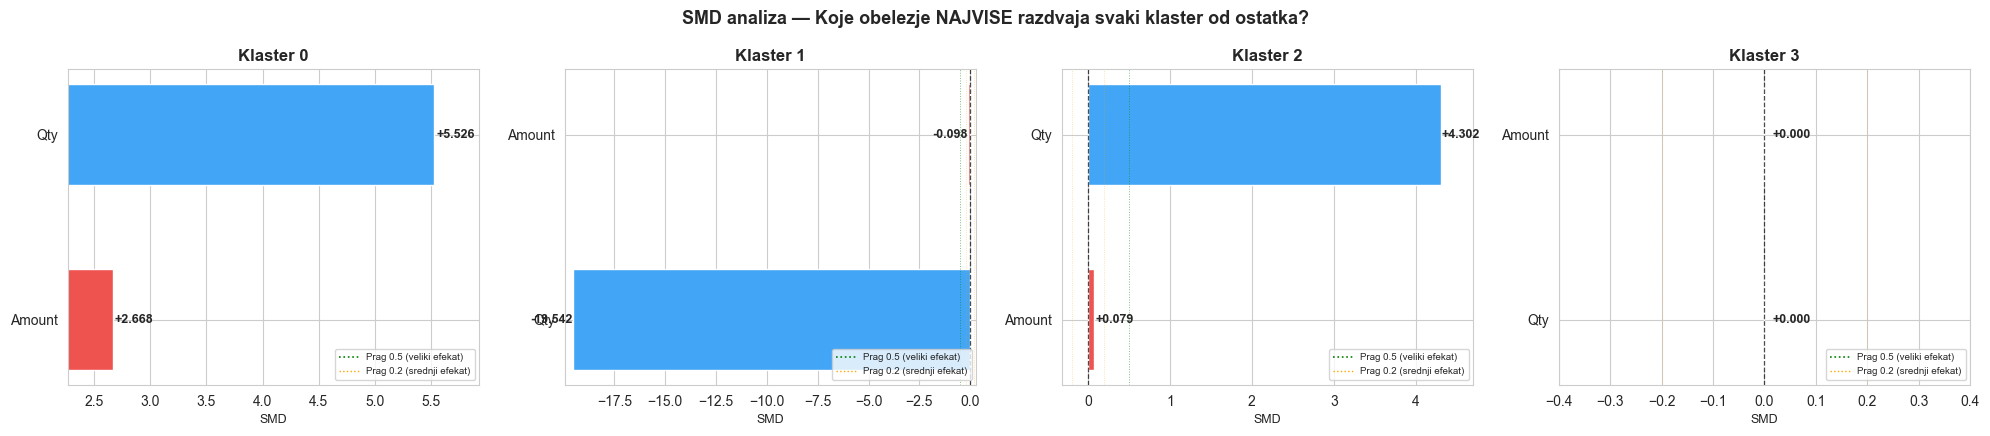

  INTERPRETACIJA — Matematicki dokaz dominantnih obelezja

Ova analiza nam matematicki dokazuje da je obelezje 'Qty' bilo
200.2x znacajnije od obelezja 'Amount' za definisanje
segmenta 'Klaster 1'.

SMD = -19.5417 znaci da je srednja vrednost 'Qty'
u Klaster 1 za 19.54 standardnih devijacija niza
od ostatka celokupnog dataseta.

→ Jacina efekta: VELIKI efekat (|SMD| > 0.50) — snazan diferenciator

Konkretne vrednosti:
  • 'Qty' — Mean u Klaster 1: 0.00  vs. ostatak: 1.00  (|SMD|=19.5417)
  • 'Amount' — Mean u Klaster 1: 617.11  vs. ostatak: 641.01  (|SMD|=0.0976)



In [33]:

# SMD analiza
# Numericka obelezja za analizu
numerical_features = ['Qty', 'Amount']

# Podaci sa dodeljenim klasterima
data_smd = data.loc[clean_indices].copy()
clusters = sorted(data_smd['Cluster_KMeans'].dropna().unique())

# Izracunavanje SMD (svaki klaster vs. ostatak) 
smd_records = []

for cluster_id in clusters:
    mask_cluster = data_smd['Cluster_KMeans'] == cluster_id
    g1 = data_smd[mask_cluster]
    g2 = data_smd[~mask_cluster]

    for feat in numerical_features:
        mean1, mean2 = g1[feat].mean(), g2[feat].mean()
        std1,  std2  = g1[feat].std(),  g2[feat].std()
        pooled_std   = np.sqrt((std1**2 + std2**2) / 2)
        smd          = (mean1 - mean2) / pooled_std if pooled_std > 0 else 0

        smd_records.append({
            'Klaster':            f'Klaster {int(cluster_id)}',
            'Obelezje':           feat,
            'Mean (klaster)':     round(mean1, 2),
            'Mean (ostatak)':     round(mean2, 2),
            'SMD':                round(smd, 4),
            '|SMD|':              round(abs(smd), 4),
        })

smd_df = pd.DataFrame(smd_records)


print("  SMD — Standardizovana razlika sredina: Klaster vs. Ostatak")

display(smd_df)

#  Rang po |SMD| za svaki klaster
print("\n Rang obelezja po apsolutnom SMD-u (unutar svakog klastera):")
for cid in clusters:
    lbl = f'Klaster {int(cid)}'
    sub = smd_df[smd_df['Klaster'] == lbl].sort_values('|SMD|', ascending=False)
    print(f"\n  {lbl}:")
    for _, row in sub.iterrows():
        direction = '▲ visi' if row['SMD'] > 0 else '▼ nizi'
        bar       = '█' * max(1, int(row['|SMD|'] * 30))
        print(f"    {row['Obelezje']:10s}: |SMD|={row['|SMD|']:.4f}  {direction} od ostatka  {bar}")

# Horizontalni bar chart po klasteru 
n_cls = len(clusters)
fig, axes = plt.subplots(1, n_cls, figsize=(5 * n_cls, max(4, len(numerical_features) * 1.2 + 2)),
                         sharey=False)
if n_cls == 1:
    axes = [axes]

palette = {'Qty': '#42A5F5', 'Amount': '#EF5350'}

for ax, cid in zip(axes, clusters):
    lbl = f'Klaster {int(cid)}'
    sub = smd_df[smd_df['Klaster'] == lbl].sort_values('SMD', ascending=True)
    bar_colors = [palette.get(f, '#90A4AE') for f in sub['Obelezje']]
    bars = ax.barh(sub['Obelezje'], sub['SMD'], color=bar_colors, edgecolor='white', height=0.55)

    ax.axvline(x=0,    color='black', lw=0.9, ls='--', alpha=0.7)
    ax.axvline(x=0.5,  color='green', lw=0.7, ls=':',  alpha=0.5)
    ax.axvline(x=-0.5, color='green', lw=0.7, ls=':',  alpha=0.5)
    ax.axvline(x=0.2,  color='orange',lw=0.6, ls=':',  alpha=0.4)
    ax.axvline(x=-0.2, color='orange',lw=0.6, ls=':',  alpha=0.4)

    for bar_obj, val in zip(bars, sub['SMD']):
        offset = 0.015 if val >= 0 else -0.015
        ha     = 'left'  if val >= 0 else 'right'
        ax.text(val + offset,
                bar_obj.get_y() + bar_obj.get_height() / 2,
                f'{val:+.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

    ax.set_title(lbl, fontsize=12, fontweight='bold')
    ax.set_xlabel('SMD', fontsize=9)
    ax.set_xlim(sub['SMD'].min() - 0.4, sub['SMD'].max() + 0.4)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='green',  lw=1.2, ls=':', label='Prag 0.5 (veliki efekat)'),
        Line2D([0], [0], color='orange', lw=1.0, ls=':', label='Prag 0.2 (srednji efekat)'),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc='lower right')

plt.suptitle('SMD analiza — Koje obelezje NAJVISE razdvaja svaki klaster od ostatka?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretacija: poredjenje obelezja unutar najboljeg klastera 
print("  INTERPRETACIJA — Matematicki dokaz dominantnih obelezja")

# Klaster sa najvecim ukupnim |SMD| (zbir po svim obelezjima)
cluster_total = smd_df.groupby('Klaster')['|SMD|'].sum()
best_cluster_lbl = cluster_total.idxmax()

# Obelezja tog klastera, sortirana po |SMD|
best_cluster_rows = smd_df[smd_df['Klaster'] == best_cluster_lbl].sort_values('|SMD|', ascending=False)
top_feat    = best_cluster_rows.iloc[0]
bottom_feat = best_cluster_rows.iloc[-1]

ratio = (top_feat['|SMD|'] / bottom_feat['|SMD|']
         if bottom_feat['|SMD|'] > 0 else float('inf'))

direction_top = "visa" if top_feat['SMD'] > 0 else "niza"

if top_feat['|SMD|'] > 0.5:
    jacina = "VELIKI efekat (|SMD| > 0.50) — snazan diferenciator"
elif top_feat['|SMD|'] > 0.2:
    jacina = "SREDNJI efekat (|SMD| > 0.20) — umereni doprinos"
else:
    jacina = "MALI efekat (|SMD| < 0.20) — slabo razdvajanje"

print(f"""
Ova analiza nam matematicki dokazuje da je obelezje '{top_feat['Obelezje']}' bilo
{ratio:.1f}x znacajnije od obelezja '{bottom_feat['Obelezje']}' za definisanje
segmenta '{best_cluster_lbl}'.

SMD = {top_feat['SMD']:+.4f} znaci da je srednja vrednost '{top_feat['Obelezje']}'
u {best_cluster_lbl} za {abs(top_feat['SMD']):.2f} standardnih devijacija {direction_top}
od ostatka celokupnog dataseta.

→ Jacina efekta: {jacina}

Konkretne vrednosti:
  • '{top_feat['Obelezje']}' — Mean u {best_cluster_lbl}: {top_feat['Mean (klaster)']:.2f}  vs. ostatak: {top_feat['Mean (ostatak)']:.2f}  (|SMD|={top_feat['|SMD|']:.4f})
  • '{bottom_feat['Obelezje']}' — Mean u {best_cluster_lbl}: {bottom_feat['Mean (klaster)']:.2f}  vs. ostatak: {bottom_feat['Mean (ostatak)']:.2f}  (|SMD|={bottom_feat['|SMD|']:.4f})
""")

### 7.2. Stratesko imenovanje segmenata

Na osnovu profila klastera, dodeljujemo smislena imena segmentima kupaca.

In [35]:
# Sortiramo klastere po prosecnom iznosu da bismo dodelili smislena imena
cluster_sorted = cluster_profile.sort_values('Mean_Amount').reset_index(drop=True)

# Dodeljujemo strateska imena na osnovu ranga
n_clusters_found = len(cluster_sorted)

if n_clusters_found == 4:
    names = ['Povremeni kupci', 'Masovna prodaja', 'Redovni kupci', 'Premium kupci']
elif n_clusters_found == 3:
    names = ['Povremeni kupci', 'Masovna prodaja', 'Premium kupci']
else:
    names = [f'Segment {i+1}' for i in range(n_clusters_found)]

cluster_sorted['Naziv segmenta'] = names

# Mapiramo naziv na originalni klaster ID
cluster_name_map = dict(zip(cluster_sorted['Cluster_KMeans'], cluster_sorted['Naziv segmenta']))
data['Segment'] = data['Cluster_KMeans'].map(cluster_name_map)

print('MAPIRANJE KLASTERA NA SEGMENTE ')
for cid, name in cluster_name_map.items():
    row = cluster_profile[cluster_profile['Cluster_KMeans'] == cid].iloc[0]
    print(f'  Klaster {cid} -> "{name}" | Prosecan iznos: {row["Mean_Amount"]:.2f} INR | Prosecna Qty: {row["Mean_Qty"]:.2f}')

print(f'\nDistribucija segmenata:')
print(data['Segment'].value_counts())

MAPIRANJE KLASTERA NA SEGMENTE 
  Klaster 1.0 -> "Povremeni kupci" | Prosecan iznos: 617.11 INR | Prosecna Qty: 0.00
  Klaster 2.0 -> "Masovna prodaja" | Prosecan iznos: 640.83 INR | Prosecna Qty: 1.00
  Klaster 0.0 -> "Redovni kupci" | Prosecan iznos: 1146.95 INR | Prosecna Qty: 3.29
  Klaster 3.0 -> "Premium kupci" | Prosecan iznos: 1176.00 INR | Prosecna Qty: 8.00

Distribucija segmenata:
Segment
Masovna prodaja    116002
Povremeni kupci      5136
Redovni kupci          41
Premium kupci           1
Name: count, dtype: int64


### 7.3. Vizualizacija segmenata kupaca

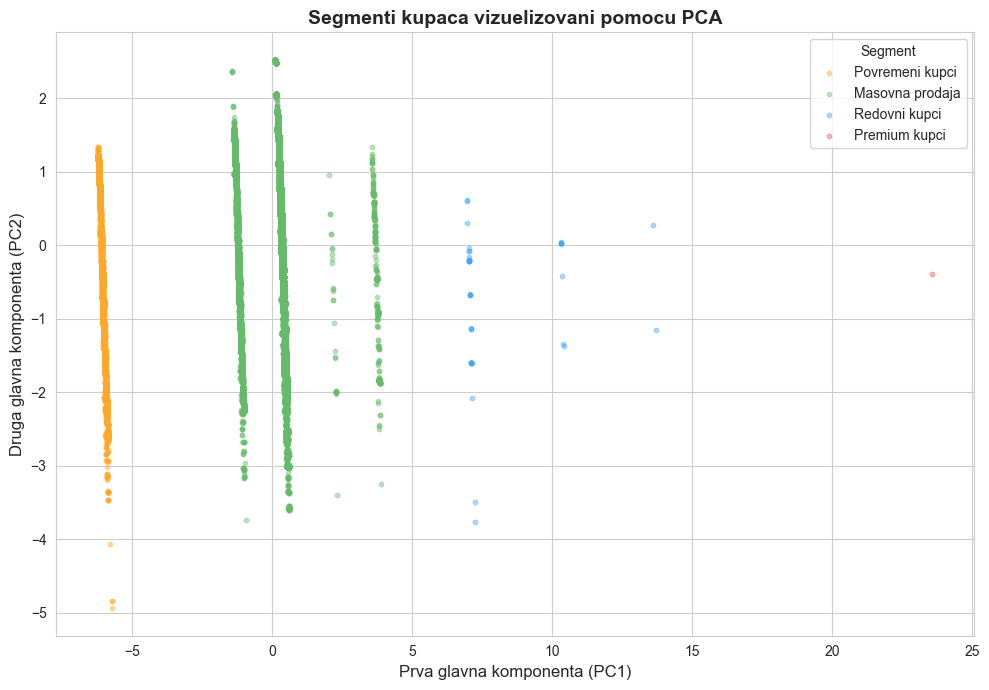

In [36]:
# Finalna vizuelizacija segmenata
# Koristimo samo redove koji imaju klaster dodelu (clean_indices)
plt.figure(figsize=(10, 7))
segment_colors = {
    'Premium kupci': '#EF5350',
    'Redovni kupci': '#42A5F5',
    'Masovna prodaja': '#66BB6A',
    'Povremeni kupci': '#FFA726'
}

# Filtriramo data da koristimo samo redove koji su korisceni u PCA
data_clean = data.loc[clean_indices].copy()

for segment_name in data_clean['Segment'].dropna().unique():
    mask = data_clean['Segment'] == segment_name
    # Koristimo boolean indeksiranje na X_pca direktno
    mask_array = mask.values
    plt.scatter(
        X_pca[mask_array, 0], X_pca[mask_array, 1],
        label=segment_name,
        alpha=0.4, s=10,
        color=segment_colors.get(segment_name, 'gray')
    )

plt.xlabel('Prva glavna komponenta (PC1)', fontsize=12)
plt.ylabel('Druga glavna komponenta (PC2)', fontsize=12)
plt.title('Segmenti kupaca vizuelizovani pomocu PCA', fontsize=14, fontweight='bold')
plt.legend(title='Segment', fontsize=10)
plt.tight_layout()
plt.show()

### 7.4. Poslovne preporuke po segmentima

| Segment | Karakteristike | Preporuka |
|---|---|---|
| **Premium kupci** | Visok iznos transakcija, manja kolicina | Ponuditi **lojaliti program** i ekskluzivne pogodnosti. Personalizovana komunikacija i VIP usluga. |
| **Redovni kupci** | Srednji iznos, redovne kupovine | Uvesti **program nagrada** za ponovljene kupovine. Personalizovane preporuke na osnovu istorije. |
| **Masovna prodaja** | Niska cena po komadu, visoka kolicina | Ponuditi **popuste za vece kolicine** i bundle pakete. Optimizovati logistiku za brzu isporuku. |
| **Povremeni kupci** | Niska frekvencija, varijabilni iznosi | Implementirati **re-engagement kampanje** i podsetnike. Popusti za povratak. |



## 8. Zakljucak

Kroz ovaj projekat uspesno je demonstrirana primena nenadgledanog ucenja na e-commerce podacima:

1. **Eksplorativna analiza** — identifikovali smo vremenske trendove prodaje i distribuciju po gradovima
2. **Predobrada** — primenili Winsorizaciju za robusnu obradu outliera umesto brisanja podataka
3. **PCA redukcija** — kompresovali 5D prostor obelezja u 2D uz zadrzavanje kljucnih informacija
4. **Klasterizacija** — implementirali i poredili K-Means, Hijerarhijsku i DBSCAN klasterizaciju
5. **Poredjenje** — na osnovu Silhouette, Calinski-Harabasz i Davies-Bouldin metrika odabrali optimalni model
6. **Profilisanje** — identifikovali 4 segmenta kupaca sa konkretnim poslovnim preporukama

Ovi rezultati mogu direktno da se primene u marketinskim kampanjama, optimizaciji zaliha i personalizaciji korisnickog iskustva na Amazon platformi.